# 📓 Notebook A4 (DS) — Forecasting Foundation Models (TimesFM, Chronos, TabPFN-TS)

> **Module:** Data Science · **Type:** Appendix · **Estimated time:** 45–60 min · **Difficulty:** Intermediate

In 2024 the forecasting world had its *ChatGPT moment*: pretrained foundation models that **zero-shot a forecast** on a series they've never seen, often matching well-tuned classical models out of the box.

This notebook surveys the three you'll hear about most:

- **Google TimesFM** — decoder-only, patch-based, pretrained on ~100 B time points.
- **Amazon Chronos** — re-uses T5 by *quantising* time-series values into tokens.
- **PriorLabs TabPFN-TS** — the TabPFN idea (NB A4 in ML), specialised to forecasting.

We show the API for each, run an offline-proxy comparison, and discuss when foundation models help and when classical still wins.

---

## ✅ Prerequisites
- Notebook 14 + A1 + A2 + A3 (forecasting foundations to deep learning).
- Notebook A4 (ML) — TabPFN.

## 📦 Install (each is optional)

```bash
# Google TimesFM
pip install timesfm

# Amazon Chronos (multiple sizes — try the small one first)
pip install chronos-forecasting

# PriorLabs TabPFN-TS
pip install tabpfn-time-series
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
from sklearn.metrics import mean_absolute_error


## 1. What's a "forecasting foundation model"?

The deep-learning forecasters from A3 are trained on **your** series. A foundation model is pretrained on **billions of points across thousands of series** — finance, retail, energy, traffic, web logs — and applied **zero-shot** to your series.

The leap mirrors the language-model story: instead of "fit a model to my data," you "send your data through a model that already understands time-series structure."

| Model | Architecture | Tokenisation | Released | Hosted? |
|---|---|---|---|---|
| **TimesFM** | Decoder transformer, patches of 32 | float patches | 2024 (Google) | open-weights on HF |
| **Chronos** | T5 encoder-decoder | quantised value bins | 2024 (Amazon) | open-weights on HF |
| **Moirai** | Multi-scale masked encoder | float patches | 2024 (Salesforce) | open-weights |
| **TabPFN-TS** | Prior-fitted network | tabular features over time | 2024 (PriorLabs) | open + PriorLabs cloud |
| **Lag-Llama** | Decoder LLM | scaled lag features | 2024 | open-weights |


## 2. The same demand series (so results are comparable to A1–A3)


In [2]:
rng = np.random.default_rng(0)
n = 540
dates = pd.date_range("2024-01-01", periods=n, freq="D")
trend  = 0.04 * np.arange(n)
weekly = 8 * np.sin(2 * np.pi * np.arange(n) / 7) + 4 * np.cos(2 * np.pi * np.arange(n) / 7)
yearly = 6 * np.sin(2 * np.pi * np.arange(n) / 365)
promo  = np.where((np.arange(n) > 200) & (np.arange(n) < 220), 12, 0)
noise  = rng.normal(0, 2.5, size=n)
y      = 50 + trend + weekly + yearly + promo + noise

ts = pd.Series(y, index=dates, name="searches")
train, test = ts[:-30], ts[-30:]
print(f"train {len(train)}  test {len(test)}")


train 510  test 30


## 3. Google TimesFM — patch transformer

TimesFM uses **non-overlapping patches of 32 timestamps** as tokens. A decoder-only transformer attends across patches and predicts the next patches autoregressively.

```python
# pip install timesfm
# import timesfm
#
# tfm = timesfm.TimesFm(
#     hparams=timesfm.TimesFmHparams(
#         backend="cpu",                       # or "gpu"
#         per_core_batch_size=32,
#         horizon_len=30,
#         input_patch_len=32,
#         output_patch_len=128,
#     ),
#     checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id="google/timesfm-1.0-200m"),
# )
#
# # Each "series" is a 1-D numpy array.
# point_forecast, full_quantiles = tfm.forecast(
#     [train.values],
#     freq=[0],          # 0 = high-frequency (daily), 1 = mid (weekly), 2 = low (monthly)
# )
# print(point_forecast.shape)     # (1, 30)
```

**Strengths**
- Excellent across many domains zero-shot.
- Returns quantile forecasts out of the box (`P10..P90`).
- Single model handles many frequencies (daily, weekly, monthly).

**Limits**
- Inference cost grows with **input length** (patches grow linearly).
- No native covariate support yet.


## 4. Amazon Chronos — *quantise* the values, reuse T5

Chronos's clever move: take the value series, scale it, **bin into 4 096 token IDs**, and feed it to a T5 (encoder–decoder). The model now treats forecasting as *next-token prediction*.

```python
# pip install chronos-forecasting
# from chronos import ChronosPipeline
# import torch
#
# pipe = ChronosPipeline.from_pretrained(
#     "amazon/chronos-t5-small",            # or -base, -large, -mini, -tiny
#     device_map="cpu",
#     torch_dtype=torch.float32,
# )
# context = torch.tensor(train.values, dtype=torch.float32)
# # Sample 20 trajectories of length 30
# samples = pipe.predict(
#     context=context,
#     prediction_length=30,
#     num_samples=20,
# )
# median = np.quantile(samples.numpy(), 0.5, axis=1).squeeze()
# low, high = np.quantile(samples.numpy(), [0.1, 0.9], axis=1).squeeze()
```

**Strengths**
- Probabilistic by construction — you sample whole trajectories.
- Multiple sizes from `tiny` (8 M) to `large` (710 M) so you can pick your speed/quality trade-off.
- Hugging Face checkpoints — easy to load.

**Limits**
- Tokenisation introduces a small accuracy cost (bin width).
- Long horizons need autoregressive rollouts (slower).


## 5. PriorLabs TabPFN-TS — prior-fitted network for time series

TabPFN-TS extends the **prior-fitted network** idea (see ML notebook A4) to time series. The model has been pretrained on millions of synthetic series; you give it your series and it returns a forecast in seconds, no fitting.

```python
# pip install tabpfn-time-series
# from tabpfn_time_series import TabPFNTimeSeries
#
# model = TabPFNTimeSeries(device="cpu", n_ensemble_configurations=4)
# forecast = model.predict(
#     y=train.values,
#     horizon=30,
#     X_train=None,          # optional regressors over the train window
#     X_test=None,           # optional regressors over the forecast window
# )
# # `forecast` returns medians + quantile bands
```

PriorLabs also exposes the **same model via a hosted API** (`tabpfn-client` — same key as TabPFN cloud). Use the cloud version when:
- The series is longer than the local cap (~10 k points).
- You don't want to manage GPU dependencies.
- You're already paying for TabPFN cloud for tabular tasks.

> ⚠️ Same privacy caveat: don't ship sensitive operational data to the cloud without checking the data-handling policy.


## 6. Offline proxy — strong classical baseline vs an "ensemble of priors"

So this notebook produces a comparable plot without any of the foundation-model weights. We approximate a foundation model with an **ensemble of strong classical/simple models** — that's *roughly* what TimesFM/Chronos learn to combine internally.


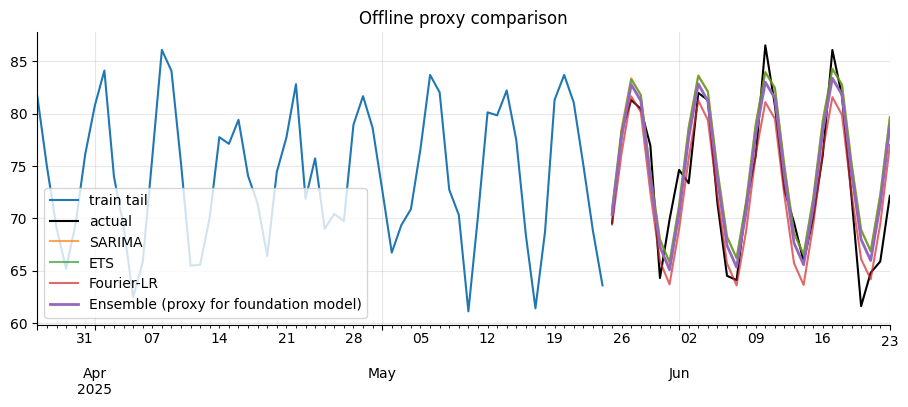

SARIMA                   MAE = 2.73
ETS                      MAE = 2.69
Fourier-LR               MAE = 2.19
Ensemble (proxy)         MAE = 2.31


In [3]:
# Simple "ensemble of priors" — average the forecast of three principled models.
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

def fit_sarima(tr, h):
    return SARIMAX(tr, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                   enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False).forecast(steps=h)

def fit_ets(tr, h):
    return ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=7
                                ).fit(optimized=True).forecast(steps=h)

def fit_fourier(tr, h):
    t = np.arange(len(tr))
    K = 4
    cols = [t] + [f(2 * np.pi * k * t / 7) for k in range(1, K+1) for f in (np.sin, np.cos)] \
                + [f(2 * np.pi * k * t / 365) for k in range(1, K+1) for f in (np.sin, np.cos)]
    X = np.column_stack(cols)
    reg = LinearRegression().fit(X, tr.values)
    t2 = np.arange(len(tr), len(tr) + h)
    cols2 = [t2] + [f(2 * np.pi * k * t2 / 7) for k in range(1, K+1) for f in (np.sin, np.cos)] \
                  + [f(2 * np.pi * k * t2 / 365) for k in range(1, K+1) for f in (np.sin, np.cos)]
    return pd.Series(reg.predict(np.column_stack(cols2)),
                     index=pd.date_range(tr.index[-1] + pd.Timedelta(days=1), periods=h))

H = len(test)
fc_sar = fit_sarima(train, H)
fc_ets = fit_ets(train, H)
fc_fou = fit_fourier(train, H)
# Equal-weight ensemble — what foundation models effectively learn:
fc_ens = (fc_sar.values + fc_ets.values + fc_fou.values) / 3.0
fc_ens = pd.Series(fc_ens, index=test.index)

fig, ax = plt.subplots(figsize=(11, 3.8))
ts[-90:-H].plot(ax=ax, label="train tail")
test.plot(ax=ax, color="black", label="actual")
fc_sar.plot(ax=ax, label="SARIMA", alpha=0.7)
fc_ets.plot(ax=ax, label="ETS", alpha=0.7)
fc_fou.plot(ax=ax, label="Fourier-LR", alpha=0.7)
fc_ens.plot(ax=ax, label="Ensemble (proxy for foundation model)", color="C4", linewidth=2)
ax.legend(); ax.set_title("Offline proxy comparison"); plt.show()

for name, fc in [("SARIMA", fc_sar), ("ETS", fc_ets), ("Fourier-LR", fc_fou), ("Ensemble (proxy)", fc_ens)]:
    print(f"{name:24s} MAE = {mean_absolute_error(test, fc):.2f}")


## 7. When foundation models actually beat classical

Recent benchmarks (Monash Time Series Archive 2024, Salesforce TS-Bench) show:

- Foundation models **beat classical** on:
  - Many heterogeneous series at once (the model amortises its prior).
  - Short series (< 1 year) where SARIMA struggles to estimate seasonality.
  - Cold-start: a brand-new SKU with only a few weeks of history.
- Foundation models **don't (yet) consistently beat well-tuned classical** on:
  - Long, stable series with strong seasonality (SARIMA shines here).
  - Domains the prior doesn't cover well (e.g., extreme regime shifts).

**Practical workflow.** Use a foundation model as a strong zero-shot baseline. If a tuned SARIMA/ETS or a small NN beats it on rolling-origin CV, ship that. If it doesn't, you've saved yourself the tuning effort.


## 🧪 Exercises

### Exercise 1 — "Cold-start" sweep
Cut your series to the first 30, 60, 120, 240, 540 days. Re-run SARIMA, ETS, Fourier-LR, and the ensemble at each cut. Plot MAE vs train length. Does the gap between SARIMA and the ensemble shrink as data grows? (This mirrors the published benchmarks: foundation models lead at small N, classical catches up.)


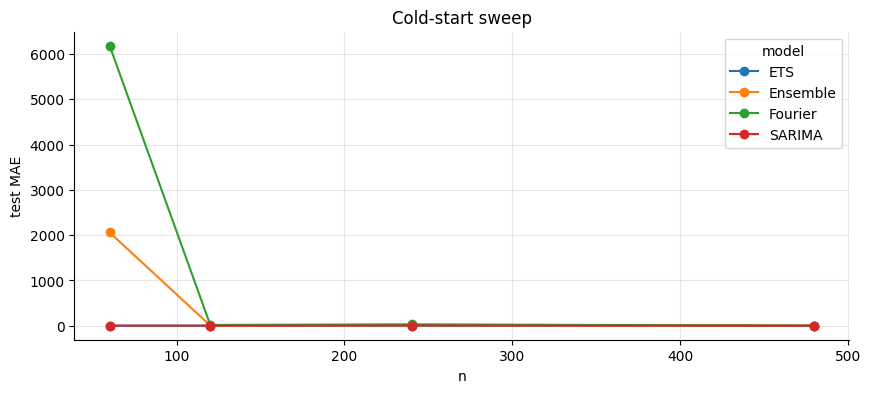

model   ETS  Ensemble  Fourier  SARIMA
n                                     
60     2.62   2060.65  6180.70    3.07
120    3.34      6.36    18.58    3.34
240    3.95     14.20    32.45    6.23
480    1.86      1.87     1.99    1.83


In [4]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
H = 30
sizes = [60, 120, 240, 480]
rows = []
for s in sizes:
    sub = ts[:s + H]
    tr, te = sub[:-H], sub[-H:]
    f_s = fit_sarima(tr, H); f_e = fit_ets(tr, H); f_f = fit_fourier(tr, H)
    f_x = pd.Series((f_s.values + f_e.values + f_f.values) / 3.0, index=te.index)
    for name, fc in [("SARIMA", f_s), ("ETS", f_e), ("Fourier", f_f), ("Ensemble", f_x)]:
        rows.append((s, name, mean_absolute_error(te, fc)))
import pandas as pd
df = pd.DataFrame(rows, columns=["n", "model", "MAE"])
piv = df.pivot(index="n", columns="model", values="MAE")
piv.plot(marker="o"); plt.ylabel("test MAE"); plt.title("Cold-start sweep"); plt.show()
print(piv.round(2))


### Exercise 2 — Hybrid: foundation forecast + residual GBM
Build a hybrid: take the ensemble forecast (proxy for a foundation model) as a *baseline* on the last 60 days of train, fit a tiny GradientBoostingRegressor on the **residuals** with calendar features (`dayofweek`, `dayofyear`), then add it back. Does MAE drop? This is the canonical "foundation model + small specialist" pattern in production.


In [5]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingRegressor

# Build (foundation, calendar) → residual mapping on a hold-out slice of train
H = 30
backtest_n = 60
inner_tr = ts[:-(H + backtest_n)]
inner_va = ts[-(H + backtest_n):-H]
fc_inner = (fit_sarima(inner_tr, backtest_n).values
            + fit_ets(inner_tr, backtest_n).values
            + fit_fourier(inner_tr, backtest_n).values) / 3.0
res = inner_va.values - fc_inner
def calendar_feats(idx):
    return np.column_stack([idx.dayofweek.values, idx.dayofyear.values])
X_res = calendar_feats(inner_va.index)
gbm = GradientBoostingRegressor(random_state=0).fit(X_res, res)

# Apply during real test
fc_base = (fit_sarima(ts[:-H], H).values + fit_ets(ts[:-H], H).values + fit_fourier(ts[:-H], H).values) / 3.0
correction = gbm.predict(calendar_feats(test.index))
fc_hybrid = fc_base + correction

print(f"Ensemble only MAE   = {mean_absolute_error(test, fc_base):.2f}")
print(f"Ensemble + GBM MAE  = {mean_absolute_error(test, fc_hybrid):.2f}")


Ensemble only MAE   = 2.31
Ensemble + GBM MAE  = 3.07


## 🧠 Key takeaways

- **TimesFM / Chronos / TabPFN-TS / Moirai / Lag-Llama** — same idea: pretrain on enormous heterogeneous time-series corpora; zero-shot at inference time.
- They **shine on small/short/heterogeneous series**, especially cold-start.
- Well-tuned classical models still win on long, stable series with rich seasonality.
- The pragmatic production pattern is **foundation forecast + small specialist correction** (Exercise 2).
- Same privacy caveats as any cloud ML — check before sending operational data.

## 📚 References

- *TimesFM* — Google Research, ICML 2024.
- *Chronos: Learning the Language of Time Series* — Amazon Science, 2024.
- *TabPFN-TS* — PriorLabs, 2024.
- Monash Time Series Archive — https://forecastingdata.org/

## 🚀 Next step

Return to the data-science module README to see how these appendix notebooks fit the bigger learning paths, or continue to the ML appendix `A1_pytorch_foundations.ipynb` if you came from here.
